In [1]:
from dmri.simulators.sphereical_distributions import Watson, hemisphere, sphere, inverse_sh_matrix, real_sh, HemiSphere
from dmri.simulators.local_signal_models import Stick
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt


/root/simformer_model_selection/dmri/dmri/simulators/sphereical_distributions.py:15: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  sphere = get_sphere("symmetric724")


In [2]:
dist = Watson(jnp.array([1.0,0.0]), 0.01)

In [3]:
pdfs = dist.pdf(sphere.vertices)

In [4]:
samples = dist.sample(jax.random.key(1), (1_000,))

In [5]:
samples.shape

(1000, 3)

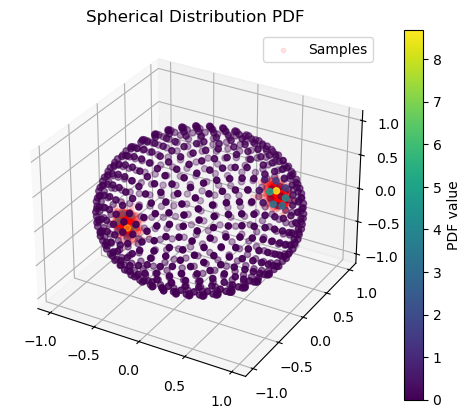

In [6]:
%matplotlib inline
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# plot sphere vertices colored by their pdf
sc = ax.scatter(sphere.vertices[:, 0],
                sphere.vertices[:, 1],
                sphere.vertices[:, 2],
                c=pdfs, cmap='viridis')
# overlay sample points in red
ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2],
           color='red', s=10, alpha=0.1, label='Samples')
plt.colorbar(sc, label='PDF value')
ax.set_title('Spherical Distribution PDF')
ax.legend()
plt.show()

In [7]:

def sh_convolution(f_distribution_sh, kernel_rh):
    r"""Spherical convolution between a fiber distribution (f) in spherical
    harmonics and a kernel in terms of rotational harmonics (oriented along the
    z-axis).

    Parameters
    ----------
    f_distribution_sh : array, shape (sh_coef)
        spherical harmonic coefficients of a fiber distribution.
    kernel_rh : array, shape (sh_coef),
        rotational harmonic coefficients of the convolution kernel. In our case
        this is the spherical signal of one micro-environment at one b-value.

    Returns
    -------
    f_kernel_convolved : array, shape (sh_coef)
        spherical harmonic coefficients of the convolved kernel and
        distribution.
    """
    sh_order_rh = 2 * (len(kernel_rh) - 1)
    number_coef_sh = len(f_distribution_sh)
    sh_order_sh = int(-3 + jnp.sqrt(9 - 4 * (2 - 2 * number_coef_sh))) // 2

    sh_order_used = min(sh_order_rh, sh_order_sh)
    number_coef_used = int((sh_order_used + 2) * (sh_order_used + 1) // 2)

    f_kernel_convolved = jnp.zeros(number_coef_used)

    counter = 0
    for n_ in range(0, sh_order_used + 1, 2):
        coef_in_order = 2 * n_ + 1
        f_kernel_convolved = f_kernel_convolved.at[counter: counter + coef_in_order].set(
            f_distribution_sh[counter: counter + coef_in_order] *
            kernel_rh[n_ // 2] * jnp.sqrt((4 * jnp.pi) / (2 * n_ + 1))
        )
        counter += coef_in_order
    return f_kernel_convolved


In [8]:
vals = jax.random.normal(jax.random.PRNGKey(0), (1000, 3))
vals = vals / jnp.linalg.norm(vals, axis=1)[:, None]
hemisphere = HemiSphere(xyz=vals)

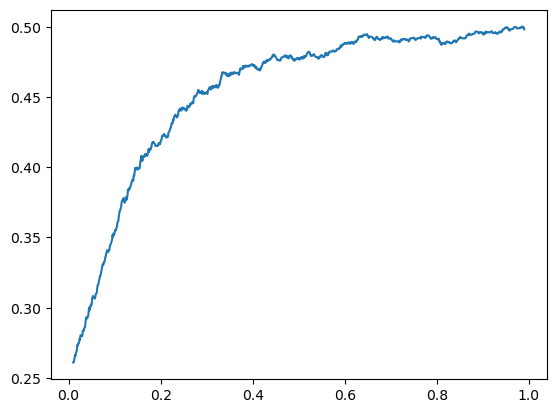

In [20]:
def kernel(v):
    return jnp.exp(-jnp.dot(v, jnp.array([1.0, 1.0, 1.0]))**2)


# Spherical convolution naive
def naive_spherical_convolution(mu, odi, kernel):
    dist = Watson(mu, odi)
    samples = dist.sample(jax.random.key(3), (1_000,))
    return jnp.mean(kernel(samples), axis=0)

mu = jnp.array([hemisphere.theta[5], hemisphere.phi[5]])
odi = 0.3

signals_mc = jax.vmap(lambda o: naive_spherical_convolution(mu, o, kernel))(jnp.linspace(0.01, 0.99, 1000))
plt.plot((jnp.linspace(0.01, 0.99, 1000)), signals_mc)

(276,)
5


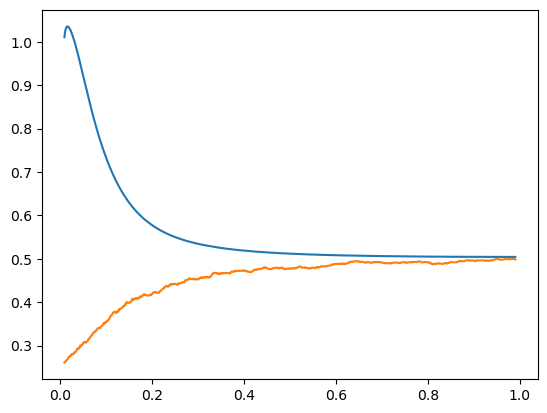

In [22]:
sh_coeff_kernel = inverse_sh_matrix(22, sphere=hemisphere)@kernel(hemisphere.vertices)

def sh_spherical_convolution(mu, odi):
    dist = Watson(mu, odi)
    basis = real_sh(22, hemisphere.theta, hemisphere.phi)[0]
    sh_coeff = dist.sh_coeff(22, sphere=hemisphere)
    print(sh_coeff.shape)
    sh_convolution_coeff = sh_convolution(sh_coeff, sh_coeff_kernel)
    reconstructed = basis @ sh_convolution_coeff
    # Convert the 2D mu into a 3D direction (assuming z=0) and normalize.
    theta, phi = mu
    mu_3d = jnp.array([jnp.sin(theta) * jnp.cos(phi),
                       jnp.sin(theta) * jnp.sin(phi),
                       jnp.cos(theta)])
    # Find the index of the vertex closest to this direction.
    idx = hemisphere.find_closest(mu_3d)
    print(idx)
    return reconstructed[idx]


signals = jax.vmap(lambda o: sh_spherical_convolution(mu, o))(jnp.linspace(0.01, 0.99, 1000))
_ = plt.plot(jnp.linspace(0.01, 0.99, 1000), signals)
_ = plt.plot(jnp.linspace(0.01, 0.99, 1000),signals_mc)

In [47]:
sh_spherical_convolution(mu, odi, kernel)

Array([0.18433045], dtype=float32)

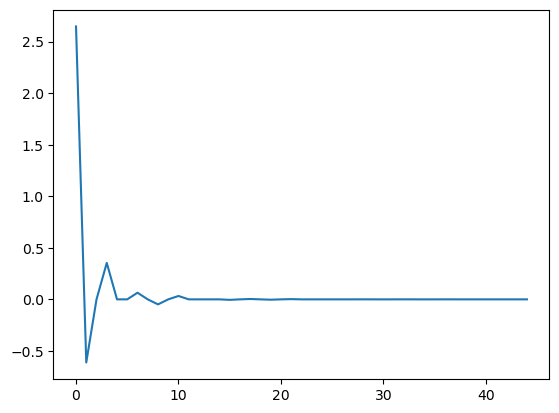

In [32]:
plt.plot(sh_coeff_kernel)

In [453]:
# naive spherical convolution

bvals = jnp.array([1000]*100)
bvecs = jax.random.normal(jax.random.key(1), (bvals.shape[0], 3))
bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)

@jax.vmap
def stick_signal(vertices):
    return jax.vmap(Stick(0.1, vertices).signal)(bvals, bvecs)

samples = dist.sample(jax.random.key(4), (20_000,))
signal = stick_signal(samples)
signal_mean = jnp.mean(signal, axis=0)

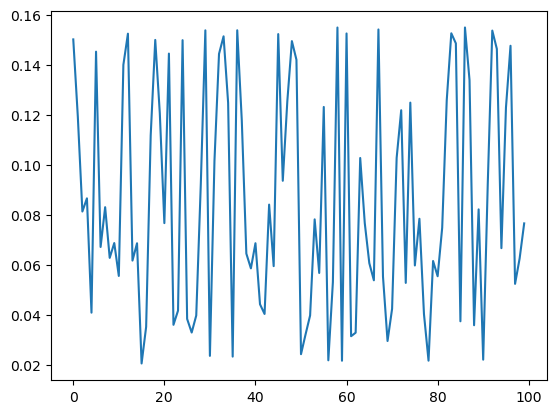

In [454]:
plt.plot(signal_mean)

In [455]:
L = 14
basis = real_sh(L, hemisphere.theta, hemisphere.phi)[0]
sh_coeff = dist.sh_coeff(sh_order=L)

In [456]:
pdfs_half = dist.pdf(hemisphere.vertices)
pdf_rec = basis @ sh_coeff

In [457]:
func_vals = stick_signal(hemisphere.vertices)

In [458]:
func_vals.shape

(362, 100)

In [459]:
sh_coeff_model = inverse_sh_matrix(L) @ func_vals

In [460]:
sh_coeff_model.shape

(120, 100)

In [461]:

def sh_convolution(f_distribution_sh, kernel_rh):
    r"""Spherical convolution between a fiber distribution (f) in spherical
    harmonics and a kernel in terms of rotational harmonics (oriented along the
    z-axis).

    Parameters
    ----------
    f_distribution_sh : array, shape (sh_coef)
        spherical harmonic coefficients of a fiber distribution.
    kernel_rh : array, shape (sh_coef),
        rotational harmonic coefficients of the convolution kernel. In our case
        this is the spherical signal of one micro-environment at one b-value.

    Returns
    -------
    f_kernel_convolved : array, shape (sh_coef)
        spherical harmonic coefficients of the convolved kernel and
        distribution.
    """
    sh_order_rh = 2 * (len(kernel_rh) - 1)
    number_coef_sh = len(f_distribution_sh)
    sh_order_sh = int(-3 + jnp.sqrt(9 - 4 * (2 - 2 * number_coef_sh))) // 2

    sh_order_used = min(sh_order_rh, sh_order_sh)
    number_coef_used = int((sh_order_used + 2) * (sh_order_used + 1) // 2)

    f_kernel_convolved = jnp.zeros(number_coef_used)

    counter = 0
    for n_ in range(0, sh_order_used + 1, 2):
        coef_in_order = 2 * n_ + 1
        f_kernel_convolved = f_kernel_convolved.at[counter: counter + coef_in_order].set(
            f_distribution_sh[counter: counter + coef_in_order] *
            kernel_rh[n_ // 2] * jnp.sqrt((4 * jnp.pi) / (2 * n_ + 1))
        )
        counter += coef_in_order
    return f_kernel_convolved


convolved = jax.vmap(sh_convolution, in_axes=(None,1))(sh_coeff, sh_coeff_model)
convolved.shape

(100, 120)

In [462]:
reconstructed_signal = basis @ convolved.T

In [468]:
def get_nearest_index(v):
    dist = jnp.linalg.norm(hemisphere.vertices - v, axis=-1)
    # Compute angular distances between v and all sphere vertices
    dist = jnp.arccos(jnp.clip(jnp.sum(hemisphere.vertices * v, axis=-1), -1.0, 1.0))
    return jnp.argmin(dist)

indices = jax.vmap(get_nearest_index)(bvecs)
print(indices)

[  4 144  72 159 305  55  17  83  34  17  92 133  10 288 280 305 161   0
  55  47  96 268 237 316   2 233 237 267  72  55 262  37  11   6 222 233
 216 288 106  88 100 233 233 360 280   2  55 345 315 268 233 233 161   4
 288  72 325  89  52 317   4 233 295  13 303 360  17  55 113 305  89 170
  64  89  17  89 269 164 317  89  89 231  16 137 144 322 226 217 305 153
 305 307   0   7 193 216  39 337 106   0]


In [469]:
reconstructed_signal[indices].shape

(100, 100)

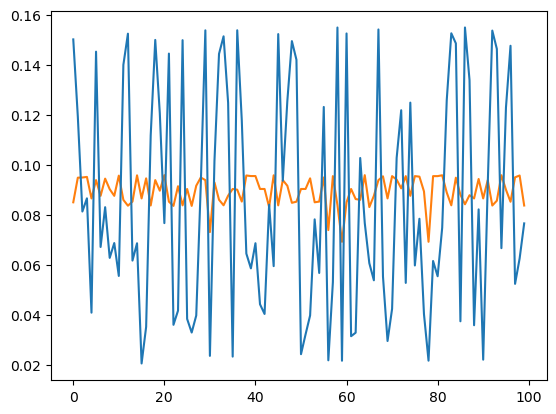

In [475]:
_ = plt.plot(reconstructed_signal[indices,1], color="C1")
plt.plot(signal_mean)